In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/loan-dataset-200000/loan_dataset_20000.csv
/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


### Library Imports 

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import rankdata

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, confusion_matrix, roc_curve, 
                            classification_report, accuracy_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from scipy.optimize import minimize

colors = ['#f6f5f5', '#fe346e', '#512b58', '#2c003e']
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette([colors[1], colors[2], colors[3]])

2025-12-21 06:11:32.004099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766297492.189438     100 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766297492.240788     100 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766297492.687819     100 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766297492.687870     100 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766297492.687873     100 computation_placer.cc:177] computation placer alr

### Data loading && Initial inspection

In [3]:
train = pd.read_csv("/kaggle/input/playground-series-s5e11/train.csv")
test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
orig = pd.read_csv('/kaggle/input/loan-dataset-200000/loan_dataset_20000.csv')
TARGET = 'loan_paid_back'

In [4]:
train = train.drop("id", axis=1)
test = test.drop("id", axis=1)

### Missing  values && Outlier treatment

In [5]:
num_cols = train.select_dtypes(exclude ='object').columns
cat_cols = train.select_dtypes(include ='object').columns
for i, col in enumerate(num_cols, 1):
    print(f'{i}. {col}')


1. annual_income
2. debt_to_income_ratio
3. credit_score
4. loan_amount
5. interest_rate
6. loan_paid_back


In [6]:
train.isnull().sum()

annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

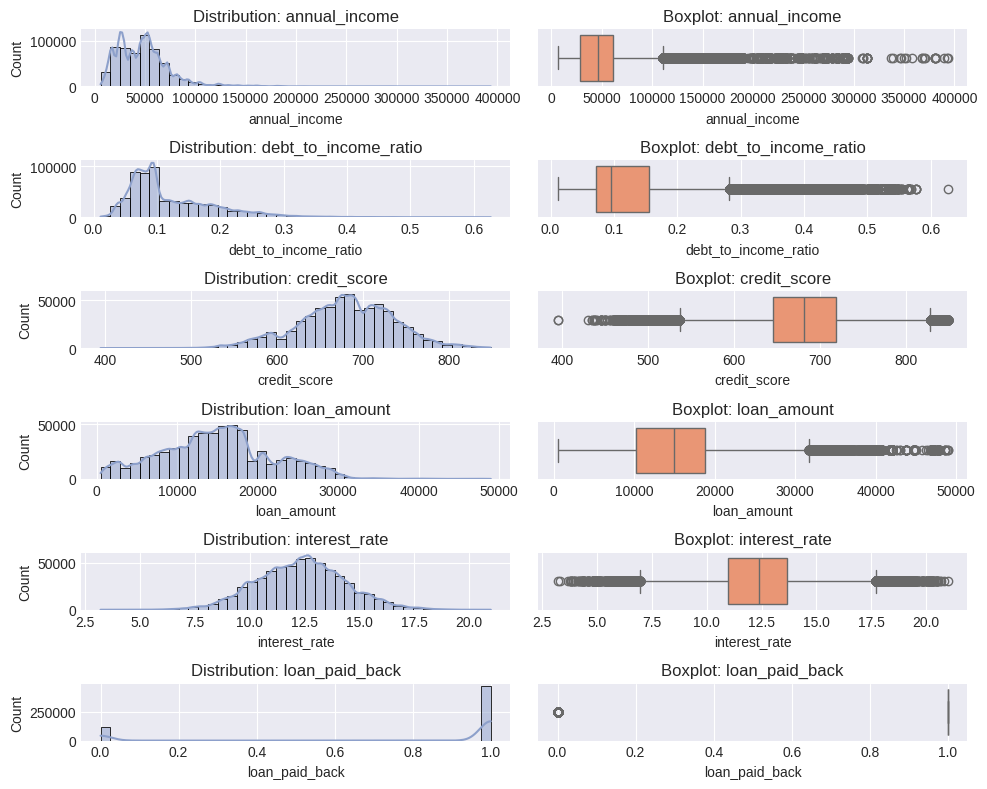

In [7]:

plt.figure(figsize=(10, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 2, 2*i - 1)
    sns.histplot(train[col], kde=True, bins=40, color="#8da0cb")
    plt.title(f'Distribution: {col}')

    plt.subplot(len(num_cols), 2, 2*i)
    sns.boxplot(x=train[col], color="#fc8d62")
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

In [8]:
num_cols=num_cols.drop('loan_paid_back')

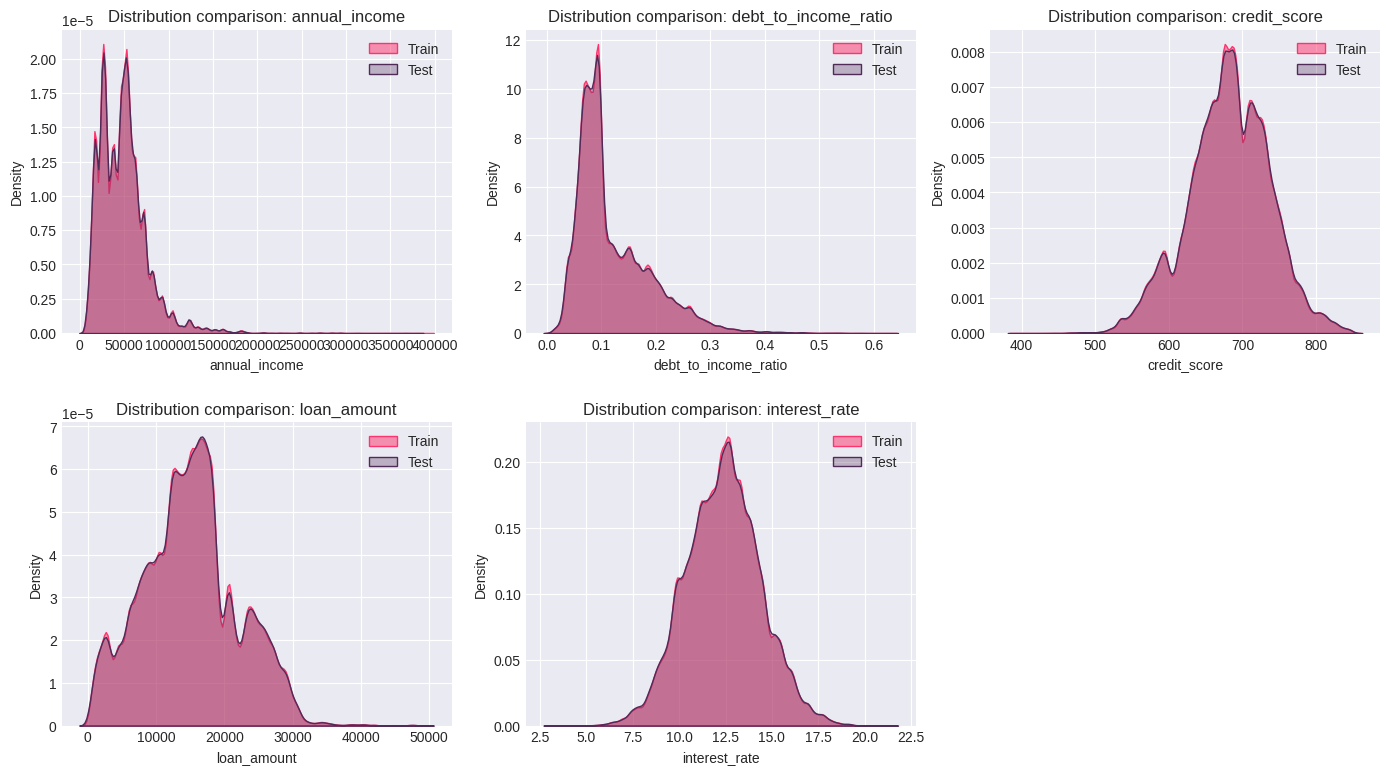

In [9]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(train[col], label='Train', fill=True, alpha=0.5)
    sns.kdeplot(test[col], label='Test', fill=True, alpha=0.3)
    plt.title(f'Distribution comparison: {col}')
    plt.legend()
plt.tight_layout()
plt.show()

In [10]:
fig = go.Figure()
target_counts = train[TARGET].value_counts()
target_pct = (target_counts / len(train) * 100).round(1)

fig.add_trace(go.Bar(y=['Status'], x=[target_pct[0]], name='Default', orientation='h',
    marker=dict(color=colors[1]), text=f'{target_pct[0]:.1f}%', textposition='inside',
    textfont=dict(size=20, color='white', family='Arial Black')))

fig.add_trace(go.Bar(y=['Status'], x=[target_pct[1]], name='Paid Back', orientation='h',
    marker=dict(color=colors[2]), text=f'{target_pct[1]:.1f}%', textposition='inside',
    textfont=dict(size=20, color='white', family='Arial Black')))

fig.update_layout(title='Loan Repayment Status Distribution', barmode='stack', height=400,
    showlegend=True, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper', x=1, y=-0.15, 
    showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [11]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Income Distribution', 'Income vs Default'))

for status in [0, 1]:
    subset = train[train[TARGET] == status]
    fig.add_trace(go.Violin(y=subset['annual_income'], 
        name='Default' if status == 0 else 'Paid Back',
        marker_color=colors[1] if status == 0 else colors[2]), row=1, col=1)

income_bins = pd.cut(train['annual_income'], bins=10)
default_rate = train.groupby(income_bins)[TARGET].agg(['mean', 'count'])
bin_centers = [interval.mid for interval in default_rate.index]

fig.add_trace(go.Scatter(x=bin_centers, y=(1 - default_rate['mean']) * 100,
    mode='markers+lines', marker=dict(size=default_rate['count']/50, color=colors[1]),
    line=dict(color=colors[2], width=3)), row=1, col=2)

fig.update_layout(height=500, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper', 
    x=1, y=-0.1, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [12]:
train['credit_bin'] = pd.cut(train['credit_score'], 
    bins=[0, 580, 670, 740, 800, 1000],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

credit_analysis = train.groupby('credit_bin').agg({TARGET: ['mean', 'count']}).reset_index()
credit_analysis.columns = ['credit_bin', 'default_rate', 'count']

fig = make_subplots(rows=1, cols=2, subplot_titles=('Credit Score by Status', 'Default Rate'))

for status in [0, 1]:
    subset = train[train[TARGET] == status]
    fig.add_trace(go.Box(y=subset['credit_score'], 
        name='Default' if status == 0 else 'Paid Back',
        marker_color=colors[1] if status == 0 else colors[2]), row=1, col=1)

fig.add_trace(go.Bar(x=credit_analysis['credit_bin'], 
    y=(1 - credit_analysis['default_rate']) * 100,
    marker=dict(color=(1 - credit_analysis['default_rate']) * 100,
    colorscale=[[0, colors[1]], [1, colors[2]]], showscale=False)), row=1, col=2)

fig.update_layout(height=500, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.1, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

train.drop('credit_bin', axis=1, inplace=True)

In [13]:
purpose_counts = train['loan_purpose'].value_counts()
purpose_default = train.groupby('loan_purpose')[TARGET].mean()

fig = go.Figure(go.Bar(y=purpose_counts.index, x=purpose_counts.values, orientation='h',
    marker=dict(color=purpose_counts.values, 
    colorscale=[[0, colors[2]], [0.5, colors[1]], [1, colors[3]]], showscale=False),
    text=[f"{val} loans" for val in purpose_counts.values], textposition='outside'))

fig.update_layout(title='Loan Purpose Distribution', height=500, 
    plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.1, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [14]:
train['grade'] = train['grade_subgrade'].str[0]
test['grade'] = test['grade_subgrade'].str[0]

grade_analysis = train.groupby('grade').agg({
    'interest_rate': ['mean', 'std', 'count'], TARGET: 'mean'}).reset_index()
grade_analysis.columns = ['grade', 'mean_rate', 'std_rate', 'count', 'default_rate']

fig = go.Figure(go.Scatter(x=grade_analysis['grade'], y=grade_analysis['mean_rate'],
    mode='markers+lines', marker=dict(size=grade_analysis['count']/100, 
    color=grade_analysis['mean_rate'], colorscale=[[0, colors[2]], [1, colors[1]]], 
    showscale=True), line=dict(color=colors[2], width=3),
    error_y=dict(type='data', array=grade_analysis['std_rate'])))

fig.update_layout(title='Interest Rate by Loan Grade', height=500,
    plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.12, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [15]:
dti_bins = pd.cut(train['debt_to_income_ratio'], bins=10)
dti_analysis = train.groupby(dti_bins).agg({
    TARGET: ['mean', 'count']}).reset_index()
dti_analysis.columns = ['dti_bin', 'default_rate', 'count']

# FIX: Convert intervals to float for multiplication
dti_analysis['bin_center'] = [interval.mid for interval in dti_analysis['dti_bin']]

fig = make_subplots(rows=2, cols=1, subplot_titles=('Default Rate', 'DTI Distribution'),
    row_heights=[0.6, 0.4])

fig.add_trace(go.Scatter(x=np.array(dti_analysis['bin_center']) * 100, 
    y=(1 - dti_analysis['default_rate']) * 100, mode='markers+lines',
    marker=dict(size=dti_analysis['count']/30, color=(1 - dti_analysis['default_rate']) * 100,
    colorscale=[[0, colors[1]], [1, colors[2]]], showscale=False),
    line=dict(color=colors[2], width=3), fill='tozeroy'), row=1, col=1)

for status in [0, 1]:
    subset = train[train[TARGET] == status]
    fig.add_trace(go.Histogram(x=subset['debt_to_income_ratio'] * 100,
        name='Default' if status == 0 else 'Paid Back',
        marker_color=colors[1] if status == 0 else colors[2], opacity=0.7), row=2, col=1)

fig.update_layout(height=700, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    barmode='overlay', annotations=[dict(text='Created By Ozan M.', xref='paper',
    yref='paper', x=1, y=-0.05, showarrow=False, font=dict(size=10, color='gray'))])
    
fig.update_xaxes(title_text='Debt-to-Income Ratio (%)', row=1, col=1)
fig.update_xaxes(title_text='Debt-to-Income Ratio (%)', row=2, col=1)
fig.update_yaxes(title_text='Default Rate (%)', row=1, col=1)
fig.update_yaxes(title_text='Frequency', row=2, col=1)

fig.show(renderer='iframe_connected')

In [16]:
employment_marital = pd.crosstab(train['employment_status'], train['marital_status'],
    values=(1 - train[TARGET]) * 100, aggfunc='mean')

fig = go.Figure(go.Heatmap(z=employment_marital.values, x=employment_marital.columns,
    y=employment_marital.index, colorscale=[[0, colors[1]], [0.5, colors[3]], [1, colors[2]]],
    text=employment_marital.values.round(1), texttemplate='%{text}%',
    textfont=dict(size=14, color='white', family='Arial Black')))

fig.update_layout(title='Employment × Marital Status Risk Matrix', height=500,
    plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.12, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [17]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Loan Amount Distribution', 'Amount vs Default'))

for status in [0, 1]:
    subset = train[train[TARGET] == status]
    fig.add_trace(go.Histogram(x=subset['loan_amount'],
        name='Default' if status == 0 else 'Paid Back',
        marker_color=colors[1] if status == 0 else colors[2], opacity=0.7), row=1, col=1)

loan_bins = pd.cut(train['loan_amount'], bins=15)
loan_analysis = train.groupby(loan_bins).agg({TARGET: ['mean', 'count']}).reset_index()
loan_analysis.columns = ['loan_bin', 'default_rate', 'count']
loan_analysis['bin_center'] = loan_analysis['loan_bin'].apply(lambda x: x.mid)

fig.add_trace(go.Scatter(x=loan_analysis['bin_center'], 
    y=(1 - loan_analysis['default_rate']) * 100, mode='markers+lines',
    marker=dict(size=loan_analysis['count']/40, color=(1 - loan_analysis['default_rate']) * 100,
    colorscale=[[0, colors[1]], [1, colors[2]]], showscale=False),
    line=dict(color=colors[2], width=3)), row=1, col=2)

fig.update_layout(height=500, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    barmode='overlay', annotations=[dict(text='Created By Ozan M.', xref='paper',
    yref='paper', x=1, y=-0.1, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [18]:
edu_analysis = train.groupby('education_level').agg({
    TARGET: ['mean', 'count'], 'annual_income': 'mean', 'credit_score': 'mean'}).reset_index()
edu_analysis.columns = ['education', 'default_rate', 'count', 'avg_income', 'avg_credit']
edu_analysis = edu_analysis.sort_values('default_rate', ascending=False)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Default Rate', 'Portfolio Distribution'),
    specs=[[{'type': 'bar'}, {'type': 'pie'}]])

fig.add_trace(go.Bar(x=edu_analysis['education'], 
    y=(1 - edu_analysis['default_rate']) * 100,
    marker=dict(color=(1 - edu_analysis['default_rate']) * 100,
    colorscale=[[0, colors[1]], [1, colors[2]]], showscale=False),
    text=[f"{val:.1f}%" for val in (1 - edu_analysis['default_rate']) * 100],
    textposition='outside'), row=1, col=1)

fig.add_trace(go.Pie(labels=edu_analysis['education'], values=edu_analysis['count'],
    marker=dict(colors=[colors[2], colors[1], colors[3], colors[2]]),
    textinfo='label+percent', hole=0.4), row=1, col=2)

fig.update_layout(height=500, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.1, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [19]:
train.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'gender', 'marital_status', 'education_level',
       'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back',
       'grade'],
      dtype='object')

In [20]:
numerical_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 
                  'loan_amount', 'interest_rate']
corr_matrix = train[numerical_cols + [TARGET]].corr()

fig = go.Figure(go.Heatmap(z=corr_matrix.values, x=corr_matrix.columns, y=corr_matrix.columns,
    colorscale=[[0, colors[1]], [0.5, colors[0]], [1, colors[2]]], zmid=0,
    text=corr_matrix.values.round(2), texttemplate='%{text}', textfont=dict(size=11)))

fig.update_layout(title='Feature Correlation Matrix', height=600, width=700,
    plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1.2, y=-0.20, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [21]:
for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
    test[col] = test[col].clip(lower=lower_bound, upper=upper_bound)

In [22]:
train['annual_income'].describe()

count    593994.000000
mean      47358.306950
std       23514.891992
min        6002.430000
25%       27934.400000
50%       46557.680000
75%       60981.320000
max      110551.700000
Name: annual_income, dtype: float64

In [23]:
train['loan_amount'].describe()

count    593994.000000
mean      14997.862742
std        6858.549604
min         500.090000
25%       10279.620000
50%       15000.220000
75%       18858.580000
max       31727.020000
Name: loan_amount, dtype: float64

In [24]:
train.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'gender', 'marital_status', 'education_level',
       'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back',
       'grade'],
      dtype='object')

In [25]:
BASE  = [col  for col in train.columns if col not in['id', TARGET, 'grade']]
for col in BASE :
    mean_map  = orig.groupby(col)[TARGET].mean()
    train[f"orig_mean_{col}"] = train[col].map(mean_map)
    test[f"orig_mean_{col}"] = test[col].map(mean_map)

    count_map = orig.groupby(col)[TARGET].size()
    train[f"orig_count_{col}"] = train[col].map(count_map)
    test[f"orig_count_{col}"] = test[col].map(count_map)




In [26]:
train ['loan_to_income'] = train['loan_amount'] / (train['annual_income']+1)
test['loan_to_income'] = test['loan_amount'] / (test['annual_income'] + 1)

train['total_debt'] = train['debt_to_income_ratio'] * train['annual_income']
test['total_debt'] = test['debt_to_income_ratio'] * test['annual_income']

train['available_income'] = train['annual_income'] * (1 - train['debt_to_income_ratio'])
test['available_income'] = test['annual_income'] * (1 - test['debt_to_income_ratio'])

train['affordability'] = train['available_income'] / (train['loan_amount'] + 1)
test['affordability'] = test['available_income'] / (test['loan_amount'] + 1)

train['monthly_payment'] = train['loan_amount'] * (1 + train['interest_rate']/100) / 12
test['monthly_payment'] = test['loan_amount'] * (1 + test['interest_rate']/100) / 12

train['payment_to_income'] = train['monthly_payment'] / (train['annual_income']/12 + 1)
test['payment_to_income'] = test['monthly_payment'] / (test['annual_income']/12 + 1)

train['risk_score'] = (train['debt_to_income_ratio'] * 40 + 
                       (1 - train['credit_score']/850) * 30 + train['interest_rate'] * 2)
test['risk_score'] = (test['debt_to_income_ratio'] * 40 + 
                      (1 - test['credit_score']/850) * 30 + test['interest_rate'] * 2)

train['grade_number'] = train['grade_subgrade'].str[1].astype(int)
test['grade_number'] = test['grade_subgrade'].str[1].astype(int)

grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
train['grade_rank'] = train['grade'].map(grade_map)
test['grade_rank'] = test['grade'].map(grade_map)

train['grade_combined'] = train['grade_rank'] * 10 + train['grade_number']
test['grade_combined'] = test['grade_rank'] * 10 + test['grade_number']

train['credit_interest'] = train['credit_score'] * train['interest_rate'] / 100
test['credit_interest'] = test['credit_score'] * test['interest_rate'] / 100

train['income_credit'] = np.log1p(train['annual_income']) * train['credit_score'] / 1000
test['income_credit'] = np.log1p(test['annual_income']) * test['credit_score'] / 1000

train['debt_loan'] = train['debt_to_income_ratio'] * np.log1p(train['loan_amount'])
test['debt_loan'] = test['debt_to_income_ratio'] * np.log1p(test['loan_amount'])

train['log_income'] = np.log1p(train['annual_income'])
test['log_income'] = np.log1p(test['annual_income'])

train['log_loan'] = np.log1p(train['loan_amount'])
test['log_loan'] = np.log1p(test['loan_amount'])

cat_cols = ['gender', 'marital_status', 'education_level', 
            'employment_status', 'loan_purpose', 'grade_subgrade']
for cat in cat_cols:
    mean_map = train.groupby(cat)['loan_amount'].mean()
    train[f'{cat}_loan_mean'] = train[cat].map(mean_map)
    test[f'{cat}_loan_mean'] = test[cat].map(mean_map)
    
    mean_map = train.groupby(cat)['credit_score'].mean()
    train[f'{cat}_credit_mean'] = train[cat].map(mean_map)
    test[f'{cat}_credit_mean'] = test[cat].map(mean_map)


num_cols = [col for col in train.columns if train[col].dtype in ['float64', 'int64'] 
            and col not in ['id', TARGET]]

for col in num_cols:
    if train[col].isnull().sum() > 0:
        median_val = train[col].median()
        train[col].fillna(median_val, inplace=True)
        test[col].fillna(median_val, inplace=True)

CATS = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'grade']
FEATURES = [col for col in train.columns if col not in ['id', TARGET] + CATS]

X = train[FEATURES].copy()
y = train[TARGET].copy()
X_test = test[FEATURES].copy()

In [27]:
train.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'gender', 'marital_status', 'education_level',
       'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back',
       'grade', 'orig_mean_annual_income', 'orig_count_annual_income',
       'orig_mean_debt_to_income_ratio', 'orig_count_debt_to_income_ratio',
       'orig_mean_credit_score', 'orig_count_credit_score',
       'orig_mean_loan_amount', 'orig_count_loan_amount',
       'orig_mean_interest_rate', 'orig_count_interest_rate',
       'orig_mean_gender', 'orig_count_gender', 'orig_mean_marital_status',
       'orig_count_marital_status', 'orig_mean_education_level',
       'orig_count_education_level', 'orig_mean_employment_status',
       'orig_count_employment_status', 'orig_mean_loan_purpose',
       'orig_count_loan_purpose', 'orig_mean_grade_subgrade',
       'orig_count_grade_subgrade', 'loan_to_income', 'total_debt',
       'available_income', 'affordabili

### MODEL 1 : XGBoost Classifier

In [28]:
N_SPLITS = 7
RANDOM_STATE = 42
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

xgb_params = {
    'objective': 'binary:logistic', 'eval_metric': 'auc', 'max_depth': 5,
    'learning_rate': 0.01, 'n_estimators': 1000, 'colsample_bytree': 0.8,
    'subsample': 0.85, 'min_child_weight': 3, 'gamma': 0.05,
    'reg_alpha': 0.05, 'reg_lambda': 1.0, 'random_state': RANDOM_STATE,
    'n_jobs': -1, 'device': 'cuda', 'tree_method': 'hist'
}

xgb_oof = np.zeros(len(X))
xgb_test = np.zeros(len(X_test))
xgb_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = XGBClassifier(**xgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)],  verbose=0)
    
    xgb_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    xgb_test += model.predict_proba(X_test)[:, 1] / N_SPLITS
    xgb_scores.append(roc_auc_score(y_val, xgb_oof[val_idx]))

xgb_cv = roc_auc_score(y, xgb_oof)
y_pred_xgb = (xgb_oof > 0.5).astype(int)
cm_xgb = confusion_matrix(y, y_pred_xgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y, xgb_oof)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Confusion Matrix', 'ROC Curve'),
    specs=[[{'type': 'heatmap'}, {'type': 'scatter'}]])

fig.add_trace(go.Heatmap(z=cm_xgb, x=['Pred Default', 'Pred Paid'], 
    y=['Act Default', 'Act Paid'], colorscale=[[0, colors[0]], [1, colors[2]]],
    text=cm_xgb, texttemplate='%{text}', textfont=dict(size=16, color=colors[3]),
    showscale=False), row=1, col=1)

fig.add_trace(go.Scatter(x=fpr_xgb, y=tpr_xgb, mode='lines',
    name=f'XGBoost (AUC={xgb_cv:.4f})', line=dict(color=colors[2], width=3)), row=1, col=2)

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random',
    line=dict(color=colors[1], width=2, dash='dash')), row=1, col=2)

fig.update_layout(title=f'XGBoost | OOF AUC: {xgb_cv:.6f} | Acc: {accuracy_score(y, y_pred_xgb):.4f}',
    height=500, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.1, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [31]:
lgb_params = {
    'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
    'max_depth': 6, 'num_leaves': 50, 'learning_rate': 0.03,
    'n_estimators': 500, 'colsample_bytree': 0.8, 'subsample': 0.8,
    'subsample_freq': 1, 'min_child_samples': 20, 'reg_alpha': 0.05,
    'reg_lambda': 0.1, 'random_state': RANDOM_STATE,
    'n_jobs': -1, 'device': 'gpu', 'verbose': -1
}

lgb_oof = np.zeros(len(X))
lgb_test = np.zeros(len(X_test))
lgb_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = LGBMClassifier(**lgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[])
    
    lgb_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    lgb_test += model.predict_proba(X_test)[:, 1] / N_SPLITS
    lgb_scores.append(roc_auc_score(y_val, lgb_oof[val_idx]))

lgb_cv = roc_auc_score(y, lgb_oof)
y_pred_lgb = (lgb_oof > 0.5).astype(int)
cm_lgb = confusion_matrix(y, y_pred_lgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y, lgb_oof)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Confusion Matrix', 'ROC Curve'),
    specs=[[{'type': 'heatmap'}, {'type': 'scatter'}]])

fig.add_trace(go.Heatmap(z=cm_lgb, x=['Pred Default', 'Pred Paid'],
    y=['Act Default', 'Act Paid'], colorscale=[[0, colors[0]], [1, colors[2]]],
    text=cm_lgb, texttemplate='%{text}', textfont=dict(size=16, color=colors[3]),
    showscale=False), row=1, col=1)

fig.add_trace(go.Scatter(x=fpr_lgb, y=tpr_lgb, mode='lines',
    name=f'LightGBM (AUC={lgb_cv:.4f})', line=dict(color=colors[2], width=3)), row=1, col=2)

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random',
    line=dict(color=colors[1], width=2, dash='dash')), row=1, col=2)

fig.update_layout(title=f'LightGBM | OOF AUC: {lgb_cv:.6f} | Acc: {accuracy_score(y, y_pred_lgb):.4f}',
    height=500, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.1, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

def create_nn_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(128), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.2),
        layers.Dense(64), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001), 
                  loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
    return model

nn_oof = np.zeros(len(X))
nn_test = np.zeros(len(X_test))
nn_scores = []
train_losses, val_losses = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values
    
    model = create_nn_model(X_scaled.shape[1])
    early_stop = callbacks.EarlyStopping(monitor='val_auc', patience=30, 
                                          mode='max', restore_best_weights=True, verbose=0)
    reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, 
                                            patience=10, mode='max', min_lr=1e-6, verbose=0)
    
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                       epochs=200, batch_size=1024, callbacks=[early_stop, reduce_lr], verbose=0)
    
    nn_oof[val_idx] = model.predict(X_val, batch_size=2048, verbose=0).flatten()
    nn_test += model.predict(X_test_scaled, batch_size=2048, verbose=0).flatten() / N_SPLITS
    nn_scores.append(roc_auc_score(y_val, nn_oof[val_idx]))
    
    if fold == 1:
        train_losses = history.history['loss']
        val_losses = history.history['val_loss']
    
    keras.backend.clear_session()

nn_cv = roc_auc_score(y, nn_oof)
y_pred_nn = (nn_oof > 0.5).astype(int)
cm_nn = confusion_matrix(y, y_pred_nn)
fpr_nn, tpr_nn, _ = roc_curve(y, nn_oof)

fig = make_subplots(rows=1, cols=3, 
    subplot_titles=('Confusion Matrix', 'ROC Curve', 'Training History'),
    specs=[[{'type': 'heatmap'}, {'type': 'scatter'}, {'type': 'scatter'}]],
    horizontal_spacing=0.12)

fig.add_trace(go.Heatmap(z=cm_nn, x=['Pred Default', 'Pred Paid'],
    y=['Act Default', 'Act Paid'], colorscale=[[0, colors[0]], [1, colors[2]]],
    text=cm_nn, texttemplate='%{text}', textfont=dict(size=16, color=colors[3]),
    showscale=False), row=1, col=1)

fig.add_trace(go.Scatter(x=fpr_nn, y=tpr_nn, mode='lines',
    name=f'Neural Net (AUC={nn_cv:.4f})', line=dict(color=colors[2], width=3)), row=1, col=2)

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random',
    line=dict(color=colors[1], width=2, dash='dash')), row=1, col=2)

fig.add_trace(go.Scatter(y=train_losses, mode='lines', name='Train Loss',
    line=dict(color=colors[2], width=2)), row=1, col=3)

fig.add_trace(go.Scatter(y=val_losses, mode='lines', name='Val Loss',
    line=dict(color=colors[1], width=2)), row=1, col=3)

fig.update_layout(title=f'Neural Network | OOF AUC: {nn_cv:.6f} | Acc: {accuracy_score(y, y_pred_nn):.4f}',
    height=500, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.1, showarrow=False, font=dict(size=10, color='gray'))])
fig.show(renderer='iframe_connected')

I0000 00:00:1766298695.513613     100 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766298695.517525     100 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1766298700.468221     306 service.cc:152] XLA service 0x7b452400c8a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766298700.468259     306 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766298700.468263     306 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766298701.107093     306 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1766298705.678553     306 device_compiler.h:188] Compiled clust

In [33]:
simple_oof = (xgb_oof + lgb_oof + nn_oof) / 3
simple_score = roc_auc_score(y, simple_oof)

total_cv = xgb_cv + lgb_cv + nn_cv
w_xgb, w_lgb, w_nn = xgb_cv/total_cv, lgb_cv/total_cv, nn_cv/total_cv
weighted_oof = w_xgb * xgb_oof + w_lgb * lgb_oof + w_nn * nn_oof
weighted_score = roc_auc_score(y, weighted_oof)

def objective(weights):
    return -roc_auc_score(y, weights[0]*xgb_oof + weights[1]*lgb_oof + weights[2]*nn_oof)

result = minimize(objective, x0=[0.33, 0.33, 0.34], method='SLSQP',
                 bounds=[(0,1)]*3, constraints={'type':'eq', 'fun':lambda w: sum(w)-1})

opt_weights = result.x
opt_oof = opt_weights[0]*xgb_oof + opt_weights[1]*lgb_oof + opt_weights[2]*nn_oof
opt_score = roc_auc_score(y, opt_oof)

methods = {
    'Simple Average': (simple_score, simple_oof, [1/3, 1/3, 1/3]),
    'CV Weighted': (weighted_score, weighted_oof, [w_xgb, w_lgb, w_nn]),
    'Optimized': (opt_score, opt_oof, opt_weights)
}

best_name, (best_score, best_oof, best_weights) = max(methods.items(), key=lambda x: x[1][0])

final_test = best_weights[0]*xgb_test + best_weights[1]*lgb_test + best_weights[2]*nn_test

y_pred_ensemble = (best_oof > 0.5).astype(int)
cm_ensemble = confusion_matrix(y, y_pred_ensemble)
fpr_ensemble, tpr_ensemble, _ = roc_curve(y, best_oof)

fig = make_subplots(rows=2, cols=2,
    subplot_titles=('Ensemble Confusion Matrix', 'Ensemble ROC Curve',
                    'Model Performance', 'Ensemble Weights'),
    specs=[[{'type':'heatmap'}, {'type':'scatter'}],
           [{'type':'bar'}, {'type':'pie'}]],
    vertical_spacing=0.15, horizontal_spacing=0.12)

fig.add_trace(go.Heatmap(z=cm_ensemble, x=['Pred Default', 'Pred Paid'],
    y=['Act Default', 'Act Paid'], colorscale=[[0, colors[0]], [1, colors[2]]],
    text=cm_ensemble, texttemplate='%{text}', 
    textfont=dict(size=18, color=colors[3], family='Arial Black'),
    showscale=False), row=1, col=1)

fig.add_trace(go.Scatter(x=fpr_xgb, y=tpr_xgb, mode='lines',
    name=f'XGBoost ({xgb_cv:.4f})', line=dict(color=colors[2], width=2, dash='dot')), row=1, col=2)

fig.add_trace(go.Scatter(x=fpr_lgb, y=tpr_lgb, mode='lines',
    name=f'LightGBM ({lgb_cv:.4f})', line=dict(color=colors[1], width=2, dash='dash')), row=1, col=2)

fig.add_trace(go.Scatter(x=fpr_nn, y=tpr_nn, mode='lines',
    name=f'Neural Net ({nn_cv:.4f})', line=dict(color='#9b59b6', width=2, dash='dashdot')), row=1, col=2)

fig.add_trace(go.Scatter(x=fpr_ensemble, y=tpr_ensemble, mode='lines',
    name=f'ENSEMBLE ({best_score:.4f})', line=dict(color=colors[3], width=4)), row=1, col=2)

fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random',
    line=dict(color='gray', width=1, dash='dot')), row=1, col=2)

models = ['XGBoost', 'LightGBM', 'Neural Net', 'ENSEMBLE']
scores = [xgb_cv, lgb_cv, nn_cv, best_score]
model_colors = [colors[2], colors[1], '#9b59b6', colors[3]]

fig.add_trace(go.Bar(x=models, y=scores, marker=dict(color=model_colors, 
    line=dict(color='white', width=2)), text=[f"{s:.6f}" for s in scores],
    textposition='outside', textfont=dict(size=12, color=colors[3], family='Arial Black')), row=2, col=1)

fig.add_trace(go.Pie(labels=['XGBoost', 'LightGBM', 'Neural Net'], values=best_weights,
    marker=dict(colors=[colors[2], colors[1], '#9b59b6']), textinfo='label+percent',
    textfont=dict(size=12, family='Arial Black'), hole=0.4), row=2, col=2)

fig.update_layout(
    title=f'FINAL ENSEMBLE | Method: {best_name} | OOF AUC: {best_score:.6f} | Acc: {accuracy_score(y, y_pred_ensemble):.4f}',
    title_font=dict(size=20, color=colors[3], family='Arial Black'),
    height=900, plot_bgcolor='#f6f5f5', paper_bgcolor='#f6f5f5',
    annotations=[dict(text='Created By Ozan M.', xref='paper', yref='paper',
    x=1, y=-0.05, showarrow=False, font=dict(size=12, color='gray'))])
fig.show(renderer='iframe_connected')